# Enhanced Voicegram-Based Dysarthric Command Recognition

## One-file project notebook

This notebook implements a complete project pipeline inspired by the paper **“Speech Vision: An End-to-End Deep Learning-Based Dysarthric Automatic Speech Recognition System.”**

The original paper converted dysarthric speech into visual acoustic representations called **voicegrams** and then used a two-dimensional convolutional neural network to classify isolated words. In this project, we keep the same core idea but use an accessible dataset and improve the model architecture.

### Project research gap

The selected paper reports that the original Spatial Convolutional Neural Network architecture can be improved because it may suffer from vanishing gradients and representational bottlenecks. This notebook investigates that gap by comparing:

1. **Baseline Convolutional Neural Network** — a simple voicegram/spectrogram image classifier.
2. **Proposed Residual-Attention Convolutional Neural Network** — a stronger model using residual connections and attention blocks.

### Dataset used

We use the **EasyCall Dysarthria Dataset** from Hugging Face: `changelinglab/easycall-dysarthria`.

EasyCall is a dysarthric command-speech corpus. It is suitable for this project because the task is command/word classification, which matches the isolated-word recognition style of the selected paper.

### Complete architecture

```text
EasyCall audio commands
        ↓
Audio preprocessing
        ↓
Voicegram-like Mel-spectrogram image generation
        ↓
Data augmentation
        ↓
Baseline CNN training
        ↓
Residual-Attention CNN training
        ↓
Metrics, graphs, confusion matrix, and prediction demo
```

### What this notebook contains

- Dataset loading/downloading from Hugging Face
- Fallback toy dataset generator if internet or dataset loading fails
- Audio preprocessing
- Voicegram-like Mel-spectrogram generation
- Exploratory dataset analysis
- Baseline CNN model
- Proposed Residual-Attention CNN model
- Training loop
- Accuracy, Precision, Recall, F1-score, Word Recognition Accuracy
- Confusion matrix
- Training/validation graphs
- Final comparison table
- Single-audio prediction function

## 1. Install required packages

Run this cell first. It installs missing packages only when needed.

> In Google Colab, Kaggle, or a local Jupyter environment, this may take a few minutes the first time.

In [1]:
import sys
import subprocess
import importlib.util

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "torch": "torch",
    "librosa": "librosa",
    "soundfile": "soundfile",
    "PIL": "pillow",
    "datasets": "datasets[audio]",
    "tqdm": "tqdm",
}

missing = []
for import_name, pip_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


## 2. Imports, configuration, and reproducibility

Change the values in this cell depending on your computer power.

Recommended starting settings:

- `MAX_CLASSES = 10`
- `MAX_SAMPLES_PER_CLASS = 80`
- `EPOCHS = 12`

For faster testing, reduce the numbers. For final results, increase them.

In [2]:
import os
import re
import math
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import matplotlib.cm as cm

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")

# -----------------------------
# Main project configuration
# -----------------------------
SEED = 42
DATASET_NAME = "changelinglab/easycall-dysarthria"

# If True, the notebook skips Hugging Face and creates a small synthetic dataset.
# Keep this False for the real project.
USE_TOY_DATASET = False

# If EasyCall download fails, the notebook automatically creates a toy dataset
# so that the whole code can still be tested end-to-end.
FALLBACK_TO_TOY_DATASET = False

# Dataset size control
MAX_CLASSES = 10
MAX_SAMPLES_PER_CLASS = 80
DYSARTHRIC_ONLY = False   # Set True only if the dataset schema allows reliable detection

# Audio and spectrogram settings
TARGET_SAMPLE_RATE = 16000
N_MELS = 128
IMAGE_SIZE = 150
N_FFT = 1024
HOP_LENGTH = 256

# Training settings
BATCH_SIZE = 32
EPOCHS = 12
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
NUM_WORKERS = 0

# Workspace folders
WORK_DIR = Path("easycall_voicegram_project_workspace")
RAW_AUDIO_DIR = WORK_DIR / "raw_audio"
SPECTROGRAM_DIR = WORK_DIR / "spectrogram_arrays"
RESULTS_DIR = WORK_DIR / "results"
MODELS_DIR = RESULTS_DIR / "models"
GRAPHS_DIR = RESULTS_DIR / "graphs"

for folder in [WORK_DIR, RAW_AUDIO_DIR, SPECTROGRAM_DIR, RESULTS_DIR, MODELS_DIR, GRAPHS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


import shutil

RESET_WORKSPACE_FOR_REAL_EASYCALL = True

if RESET_WORKSPACE_FOR_REAL_EASYCALL:
    for folder in [RAW_AUDIO_DIR, SPECTROGRAM_DIR]:
        if folder.exists():
            shutil.rmtree(folder)
        folder.mkdir(parents=True, exist_ok=True)

    print("Old toy/raw audio and spectrogram cache cleared.")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Workspace:", WORK_DIR.resolve())

Old toy/raw audio and spectrogram cache cleared.
Device: cuda
Workspace: /teamspace/studios/this_studio/Speech_NLP_Project/easycall_voicegram_project_workspace


## 3. Utility functions

These helper functions keep the notebook clean.

They handle label cleaning, audio normalization, automatic dataset-column detection, and path management.

In [3]:
def sanitize_label(value):
    """Convert labels such as 'Apri Contatti' into clean folder-safe labels."""
    value = str(value).strip().lower()
    value = re.sub(r"[^a-zA-Z0-9_\-]+", "_", value)
    value = re.sub(r"_+", "_", value).strip("_")
    return value if value else "unknown"


def normalize_audio(y):
    """Convert audio to mono float32 and normalize amplitude safely."""
    y = np.asarray(y, dtype=np.float32)
    if y.ndim > 1:
        y = y.mean(axis=1)
    if len(y) == 0:
        y = np.zeros(TARGET_SAMPLE_RATE // 2, dtype=np.float32)
    max_val = np.max(np.abs(y))
    if max_val > 1e-8:
        y = y / max_val
    return y.astype(np.float32)


def trim_and_prepare_audio(y, sr, target_sr=TARGET_SAMPLE_RATE):
    """Resample, trim silence, normalize, and ensure a minimum duration."""
    y = normalize_audio(y)
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    y, _ = librosa.effects.trim(y, top_db=30)
    y = normalize_audio(y)
    min_len = int(0.30 * target_sr)
    if len(y) < min_len:
        y = np.pad(y, (0, min_len - len(y)))
    return y.astype(np.float32), target_sr


def detect_audio_column(dataset_split):
    """Try to find the audio column in a Hugging Face dataset split."""
    columns = list(dataset_split.column_names)
    preferred = ["audio", "file", "wav", "speech", "path"]
    lower_map = {c.lower(): c for c in columns}

    for name in preferred:
        if name in lower_map:
            return lower_map[name]

    for col in columns:
        lc = col.lower()
        if any(name in lc for name in preferred):
            return col

    first = dataset_split[0]
    for col, value in first.items():
        if isinstance(value, dict) and any(k in value for k in ["array", "path", "bytes", "sampling_rate"]):
            return col

    raise ValueError(f"Could not detect audio column. Available columns: {columns}")


def detect_label_column(dataset_split, audio_col):
    """Try to find the command/text label column."""
    columns = list(dataset_split.column_names)
    preferred = [
        "transcription", "transcript", "sentence", "text", "label",
        "command", "word", "phrase", "prompt", "target",
    ]
    lower_map = {c.lower(): c for c in columns}

    for name in preferred:
        if name in lower_map and lower_map[name] != audio_col:
            return lower_map[name]

    for col in columns:
        if col == audio_col:
            continue
        lc = col.lower()
        if any(name in lc for name in preferred):
            return col

    first = dataset_split[0]
    for col, value in first.items():
        if col == audio_col:
            continue
        if isinstance(value, str) and value.strip():
            return col

    raise ValueError(f"Could not detect label column. Available columns: {columns}")


def detect_optional_column(dataset_split, candidates):
    columns = list(dataset_split.column_names)
    lower_map = {c.lower(): c for c in columns}
    for name in candidates:
        if name in lower_map:
            return lower_map[name]
    for col in columns:
        lc = col.lower()
        if any(name in lc for name in candidates):
            return col
    return None


def row_to_audio(row, audio_col):
    """Convert a Hugging Face row audio value into (audio_array, sampling_rate)."""
    value = row[audio_col]

    if isinstance(value, dict):
        if value.get("array") is not None:
            y = np.asarray(value["array"], dtype=np.float32)
            sr = int(value.get("sampling_rate") or TARGET_SAMPLE_RATE)
            return y, sr
        if value.get("bytes") is not None:
            import io
            y, sr = sf.read(io.BytesIO(value["bytes"]), dtype="float32")
            return y, int(sr)
        if value.get("path") is not None:
            y, sr = sf.read(value["path"], dtype="float32")
            return y, int(sr)

    if isinstance(value, (str, Path)):
        y, sr = sf.read(value, dtype="float32")
        return y, int(sr)

    raise ValueError(f"Unsupported audio value type: {type(value)}")

def row_to_audio_no_torchcodec(row, audio_col):
    """
    Read EasyCall audio without using Hugging Face TorchCodec decoding.

    This is required because the notebook failed at Audio(decode=True)
    due to TorchCodec / FFmpeg / PyTorch mismatch.
    """
    import io

    value = row[audio_col]

    if isinstance(value, dict):
        audio_bytes = value.get("bytes", None)
        audio_path = value.get("path", None)

        if audio_bytes is not None:
            y, sr = sf.read(io.BytesIO(audio_bytes), dtype="float32")
            return y, int(sr)

        if audio_path is not None and Path(audio_path).exists():
            y, sr = sf.read(audio_path, dtype="float32")
            return y, int(sr)

        raise ValueError(f"Audio dict has no readable bytes/path. Keys: {value.keys()}")

    if isinstance(value, (str, Path)):
        y, sr = sf.read(str(value), dtype="float32")
        return y, int(sr)

    raise ValueError(f"Unsupported audio value type: {type(value)}")

def maybe_is_dysarthric(row, severity_col):
    """Best-effort detection of dysarthric/control rows from metadata."""
    if severity_col is None or severity_col not in row:
        return None

    value = row[severity_col]
    text = str(value).strip().lower()

    if text in {"control", "healthy", "normal", "hc", "non_dysarthric", "non-dysarthric"}:
        return False
    if text in {"dysarthric", "patient", "impaired", "pathological", "dys"}:
        return True

    try:
        number = float(value)
        if math.isfinite(number):
            return number > 0
    except Exception:
        pass

    return None

## 4. Dataset loading

This cell tries to download and export a subset of EasyCall from Hugging Face.

If the dataset cannot be loaded because of internet issues, missing permissions, or environment limitations, the notebook automatically creates a small toy audio dataset. This fallback is only for testing the code. For final project results, use the real EasyCall dataset.

In [4]:
def create_toy_dataset(
    output_dir=RAW_AUDIO_DIR,
    max_classes=4,
    samples_per_class=40,
    target_sr=TARGET_SAMPLE_RATE,
    seed=SEED,
):
    """Create a small synthetic command-like dataset for offline testing."""
    seed_everything(seed)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    base_commands = [
        "apri_contatti", "chiama", "fine_chiamata", "messaggio",
        "rubrica", "sezione", "volume_su", "volume_giu",
    ]
    commands = base_commands[:max_classes]
    rows = []

    duration = 0.85
    t = np.linspace(0, duration, int(target_sr * duration), endpoint=False)

    for class_idx, label in enumerate(commands):
        base_freq = 220 + class_idx * 80
        for sample_idx in range(samples_per_class):
            freq_shift = np.random.uniform(-12, 12)
            speed = np.random.uniform(0.92, 1.08)
            amp = np.random.uniform(0.55, 0.95)

            y = amp * np.sin(2 * np.pi * (base_freq + freq_shift) * t)
            y += 0.35 * amp * np.sin(2 * np.pi * (base_freq * 1.7 + freq_shift) * t)
            y *= np.hanning(len(y))
            y += np.random.normal(0, 0.015, size=len(y))

            if speed != 1.0:
                new_len = max(100, int(len(y) / speed))
                y = np.interp(
                    np.linspace(0, len(y) - 1, new_len),
                    np.arange(len(y)),
                    y,
                ).astype(np.float32)

            y, sr = trim_and_prepare_audio(y, target_sr, target_sr)
            wav_dir = output_dir / label
            wav_dir.mkdir(parents=True, exist_ok=True)
            wav_path = wav_dir / f"toy_{label}_{sample_idx:04d}.wav"
            sf.write(wav_path, y, sr)

            rows.append({
                "audio_path": str(wav_path),
                "label": label,
                "raw_label": label,
                "speaker_id": f"toy_speaker_{sample_idx % 6}",
                "severity": "toy",
                "is_dysarthric_detected": None,
                "source_dataset": "toy_synthetic_dataset",
            })

    metadata = pd.DataFrame(rows)
    metadata_path = output_dir / "metadata.csv"
    metadata.to_csv(metadata_path, index=False)
    print(f"Toy dataset created: {metadata_path}")
    return metadata


def load_easycall_subset(
    dataset_name=DATASET_NAME,
    output_dir=RAW_AUDIO_DIR,
    max_classes=MAX_CLASSES,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    dysarthric_only=DYSARTHRIC_ONLY,
    target_sr=TARGET_SAMPLE_RATE,
):
    """Download/export an EasyCall subset into local WAV files and metadata."""
    from datasets import load_dataset, Audio, DatasetDict, concatenate_datasets

    output_dir = Path(output_dir)
    audio_output_dir = output_dir / "audio"
    audio_output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Loading Hugging Face dataset: {dataset_name}")
    dataset_obj = load_dataset(dataset_name)

    if isinstance(dataset_obj, DatasetDict):
        split_names = list(dataset_obj.keys())
        print("Available splits:", split_names)
        split_datasets = [dataset_obj[name] for name in split_names]
        dataset_split = concatenate_datasets(split_datasets) if len(split_datasets) > 1 else split_datasets[0]
    else:
        dataset_split = dataset_obj

    print("Total rows before filtering:", len(dataset_split))
    print("Columns:", dataset_split.column_names)

    audio_col = detect_audio_column(dataset_split)
    label_col = detect_label_column(dataset_split, audio_col)
    speaker_col = detect_optional_column(dataset_split, ["speaker_id", "speaker", "spk", "subject", "patient"])
    severity_col = detect_optional_column(dataset_split, ["tom", "therapy", "severity", "dysarthria", "status", "class", "group", "impairment"])

    print("Detected audio column   :", audio_col)
    print("Detected label column   :", label_col)
    print("Detected speaker column :", speaker_col)
    print("Detected severity column:", severity_col)

    # Select top labels using metadata only.
    labels = [sanitize_label(x) for x in dataset_split[label_col]]
    label_counts = Counter(labels)
    selected_labels = [label for label, _ in label_counts.most_common(max_classes)]
    selected_set = set(selected_labels)
    print("Selected labels:", selected_labels)

    # Decode audio after label selection.
    # IMPORTANT FIX:
    # Do not use decode=True because it uses TorchCodec and caused the notebook failure.
    # We keep decode=False and manually read audio bytes/path using soundfile.
    dataset_split = dataset_split.cast_column(audio_col, Audio(decode=False))

    rows = []
    per_class_counter = Counter()

    for i, row in enumerate(tqdm(dataset_split, desc="Exporting selected audio")):
        label = sanitize_label(row[label_col])
        if label not in selected_set:
            continue
        if per_class_counter[label] >= max_samples_per_class:
            continue

        is_dys = maybe_is_dysarthric(row, severity_col)
        if dysarthric_only and is_dys is False:
            continue

        try:
            y, sr = row_to_audio_no_torchcodec(row, audio_col)
            y, sr = trim_and_prepare_audio(y, sr, target_sr)
        except Exception as exc:
            print(f"Skipping row {i} because audio could not be read: {exc}")
            continue

        speaker_id = str(row.get(speaker_col, "unknown_speaker")) if speaker_col else "unknown_speaker"
        severity = str(row.get(severity_col, "unknown")) if severity_col else "unknown"

        wav_dir = audio_output_dir / label
        wav_dir.mkdir(parents=True, exist_ok=True)
        wav_path = wav_dir / f"easycall_{sanitize_label(speaker_id)}_{label}_{per_class_counter[label]:05d}.wav"
        sf.write(wav_path, y, sr)

        rows.append({
            "audio_path": str(wav_path),
            "label": label,
            "raw_label": str(row[label_col]),
            "speaker_id": speaker_id,
            "severity": severity,
            "is_dysarthric_detected": is_dys,
            "source_dataset": dataset_name,
        })
        per_class_counter[label] += 1

        if all(per_class_counter[label] >= max_samples_per_class for label in selected_labels):
            break

    metadata = pd.DataFrame(rows)
    if metadata.empty:
        raise RuntimeError("No rows were exported from EasyCall. Try reducing filters or using toy data.")

    metadata_path = output_dir / "metadata.csv"
    metadata.to_csv(metadata_path, index=False)
    print(f"Exported metadata saved at: {metadata_path}")
    return metadata


def get_project_metadata():
    """Main entry point: load EasyCall or create toy fallback."""
    if USE_TOY_DATASET:
        return create_toy_dataset(max_classes=min(MAX_CLASSES, 4), samples_per_class=40)

    try:
        return load_easycall_subset()
    except Exception as exc:
        print("\nEasyCall loading failed.")
        print("Reason:", repr(exc))
        if FALLBACK_TO_TOY_DATASET:
            print("\nCreating toy dataset so the notebook can still run end-to-end.")
            return create_toy_dataset(max_classes=min(MAX_CLASSES, 4), samples_per_class=40)
        raise

metadata = get_project_metadata()
metadata.head()

Loading Hugging Face dataset: changelinglab/easycall-dysarthria


Available splits: ['test', 'train', 'validation']
Total rows before filtering: 21386
Columns: ['audio', 'filename', 'speaker', 'text', 'dysarthria_severity']
Detected audio column   : audio
Detected label column   : text
Detected speaker column : speaker
Detected severity column: dysarthria_severity
Selected labels: ['otto', 'sette', 'deseleziona', 'nuovo_contatto', 'stop', 'vai_nei_preferiti', 'chiama_emergenza', 'no', 'aggiungi', 'chiama_ultimo_numero']


Exporting selected audio:   0%|          | 0/21386 [00:00<?, ?it/s]

Exported metadata saved at: easycall_voicegram_project_workspace/raw_audio/metadata.csv


,audio_path,label,raw_label,speaker_id,severity,is_dysarthric_detected,source_dataset
0,easycall_voicegram_project_workspace/raw_audio...,stop,stop,fc10,0,False,changelinglab/easycall-dysarthria
1,easycall_voicegram_project_workspace/raw_audio...,vai_nei_preferiti,vai nei preferiti,fc10,0,False,changelinglab/easycall-dysarthria
2,easycall_voicegram_project_workspace/raw_audio...,chiama_emergenza,chiama emergenza,fc10,0,False,changelinglab/easycall-dysarthria
3,easycall_voicegram_project_workspace/raw_audio...,no,no,fc10,0,False,changelinglab/easycall-dysarthria
4,easycall_voicegram_project_workspace/raw_audio...,aggiungi,aggiungi,fc10,0,False,changelinglab/easycall-dysarthria


## 5. Dataset exploration

This section shows the dataset size, number of command classes, and class distribution.

In [5]:
print("Total samples:", len(metadata))
print("Number of classes:", metadata["label"].nunique())
print("Source dataset values:")
print(metadata["source_dataset"].value_counts())

metadata.head(10)

Total samples: 800
Number of classes: 10
Source dataset values:
source_dataset
changelinglab/easycall-dysarthria    800
Name: count, dtype: int64


,audio_path,label,raw_label,speaker_id,severity,is_dysarthric_detected,source_dataset
0,easycall_voicegram_project_workspace/raw_audio...,stop,stop,fc10,0,False,changelinglab/easycall-dysarthria
1,easycall_voicegram_project_workspace/raw_audio...,vai_nei_preferiti,vai nei preferiti,fc10,0,False,changelinglab/easycall-dysarthria
2,easycall_voicegram_project_workspace/raw_audio...,chiama_emergenza,chiama emergenza,fc10,0,False,changelinglab/easycall-dysarthria
3,easycall_voicegram_project_workspace/raw_audio...,no,no,fc10,0,False,changelinglab/easycall-dysarthria
4,easycall_voicegram_project_workspace/raw_audio...,aggiungi,aggiungi,fc10,0,False,changelinglab/easycall-dysarthria
5,easycall_voicegram_project_workspace/raw_audio...,chiama_ultimo_numero,chiama ultimo numero,fc10,0,False,changelinglab/easycall-dysarthria
6,easycall_voicegram_project_workspace/raw_audio...,otto,otto,fc10,0,False,changelinglab/easycall-dysarthria
7,easycall_voicegram_project_workspace/raw_audio...,sette,sette,fc10,0,False,changelinglab/easycall-dysarthria
8,easycall_voicegram_project_workspace/raw_audio...,deseleziona,deseleziona,fc10,0,False,changelinglab/easycall-dysarthria
9,easycall_voicegram_project_workspace/raw_audio...,nuovo_contatto,nuovo contatto,fc10,0,False,changelinglab/easycall-dysarthria


label
stop                    80
vai_nei_preferiti       80
chiama_emergenza        80
no                      80
aggiungi                80
chiama_ultimo_numero    80
otto                    80
sette                   80
deseleziona             80
nuovo_contatto          80
Name: count, dtype: int64


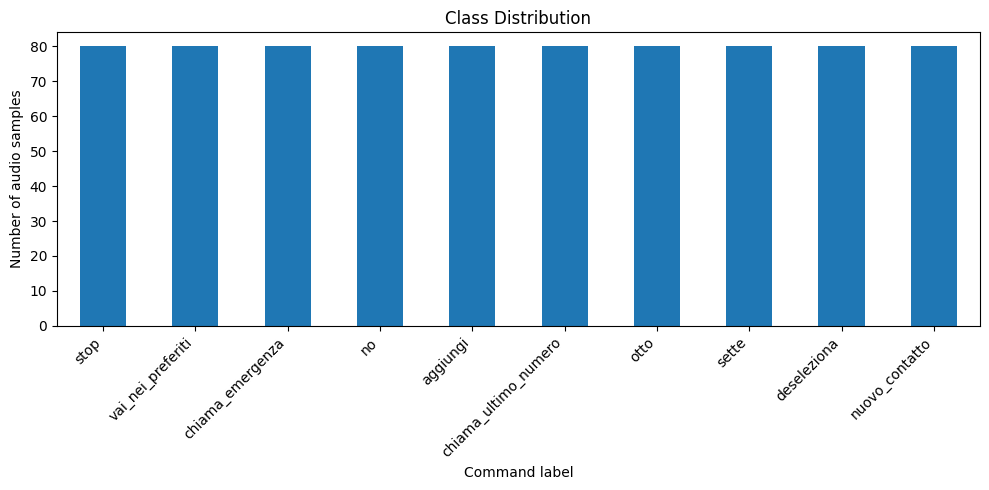

In [6]:
class_counts = metadata["label"].value_counts().sort_values(ascending=False)
print(class_counts)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Command label")
plt.ylabel("Number of audio samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Listen to one sample and visualize waveform

This helps us confirm that the audio files are being loaded correctly.

Sample label: stop
Sample path: easycall_voicegram_project_workspace/raw_audio/audio/stop/easycall_fc10_stop_00000.wav


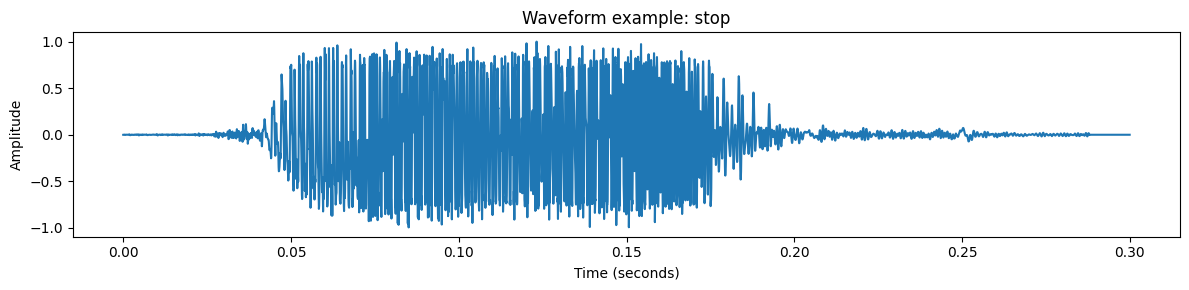

In [7]:
# Select one example audio file
sample_row = metadata.iloc[0]
sample_audio_path = sample_row["audio_path"]
print("Sample label:", sample_row["label"])
print("Sample path:", sample_audio_path)

sample_y, sample_sr = librosa.load(sample_audio_path, sr=TARGET_SAMPLE_RATE, mono=True)

plt.figure(figsize=(12, 3))
plt.plot(np.arange(len(sample_y)) / TARGET_SAMPLE_RATE, sample_y)
plt.title(f"Waveform example: {sample_row['label']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# In Jupyter/Colab this displays an audio player.
try:
    from IPython.display import Audio, display
    display(Audio(sample_y, rate=TARGET_SAMPLE_RATE))
except Exception:
    print("Audio display not available in this environment.")

## 7. Voicegram-like Mel-spectrogram generation

The selected paper used visual representations of speech called **voicegrams**. Here we implement a voicegram-like representation using a Mel-spectrogram heatmap.

The flow is:

```text
Audio waveform → Mel-spectrogram → decibel scale → normalized heatmap → resized RGB image
```

This transforms the speech-recognition problem into an image-classification problem.

Voicegram shape: (150, 150, 3)


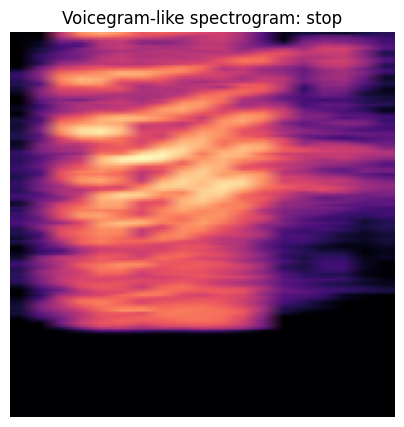

In [8]:
def audio_to_voicegram_array(
    audio_path,
    target_sr=TARGET_SAMPLE_RATE,
    n_mels=N_MELS,
    image_size=IMAGE_SIZE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    cmap_name="magma",
):
    """Convert an audio file into an RGB voicegram-like Mel-spectrogram array."""
    y, sr = librosa.load(audio_path, sr=target_sr, mono=True)
    y, sr = trim_and_prepare_audio(y, sr, target_sr)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    rgba = cm.get_cmap(cmap_name)(mel_norm)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    image = Image.fromarray(rgb).resize((image_size, image_size), Image.Resampling.BILINEAR)
    arr = np.asarray(image).astype(np.float32) / 255.0
    return arr


sample_voicegram = audio_to_voicegram_array(sample_audio_path)
print("Voicegram shape:", sample_voicegram.shape)

plt.figure(figsize=(5, 5))
plt.imshow(sample_voicegram)
plt.title(f"Voicegram-like spectrogram: {sample_row['label']}")
plt.axis("off")
plt.show()

## 8. Generate cached spectrogram arrays for all audio files

To make training faster, we convert every audio file once and save it as a `.npy` array.

In [9]:
def generate_spectrogram_cache(metadata_df, output_dir=SPECTROGRAM_DIR):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for idx, row in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Generating spectrogram cache"):
        label = row["label"]
        class_dir = output_dir / label
        class_dir.mkdir(parents=True, exist_ok=True)
        out_path = class_dir / f"{idx:06d}_{label}.npy"

        if not out_path.exists():
            try:
                arr = audio_to_voicegram_array(row["audio_path"])
                np.save(out_path, arr.astype(np.float32))
            except Exception as exc:
                print(f"Skipping {row['audio_path']} because spectrogram failed: {exc}")
                continue

        new_row = row.to_dict()
        new_row["spectrogram_path"] = str(out_path)
        rows.append(new_row)

    cached_df = pd.DataFrame(rows)
    cached_metadata_path = output_dir / "metadata_spectrograms.csv"
    cached_df.to_csv(cached_metadata_path, index=False)
    print("Saved spectrogram metadata:", cached_metadata_path)
    return cached_df

metadata_spec = generate_spectrogram_cache(metadata)
metadata_spec.head()

Generating spectrogram cache:   0%|          | 0/800 [00:00<?, ?it/s]

Saved spectrogram metadata: easycall_voicegram_project_workspace/spectrogram_arrays/metadata_spectrograms.csv


,audio_path,label,raw_label,speaker_id,severity,is_dysarthric_detected,source_dataset,spectrogram_path
0,easycall_voicegram_project_workspace/raw_audio...,stop,stop,fc10,0,False,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
1,easycall_voicegram_project_workspace/raw_audio...,vai_nei_preferiti,vai nei preferiti,fc10,0,False,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
2,easycall_voicegram_project_workspace/raw_audio...,chiama_emergenza,chiama emergenza,fc10,0,False,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
3,easycall_voicegram_project_workspace/raw_audio...,no,no,fc10,0,False,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...
4,easycall_voicegram_project_workspace/raw_audio...,aggiungi,aggiungi,fc10,0,False,changelinglab/easycall-dysarthria,easycall_voicegram_project_workspace/spectrogr...


## 9. Train/validation/test split

We split the data in a stratified way so every command class is represented in training, validation, and testing.

In [10]:
# Remove classes with too few examples for stratified splitting
min_required_per_class = 3
valid_labels = metadata_spec["label"].value_counts()
valid_labels = valid_labels[valid_labels >= min_required_per_class].index.tolist()
metadata_spec = metadata_spec[metadata_spec["label"].isin(valid_labels)].reset_index(drop=True)

label_names = sorted(metadata_spec["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}
metadata_spec["label_idx"] = metadata_spec["label"].map(label_to_idx)

train_df, temp_df = train_test_split(
    metadata_spec,
    test_size=0.30,
    random_state=SEED,
    stratify=metadata_spec["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
print("Classes:", label_names)

split_summary = pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).fillna(0).astype(int)

split_summary

Train samples: 560
Validation samples: 120
Test samples: 120
Classes: ['aggiungi', 'chiama_emergenza', 'chiama_ultimo_numero', 'deseleziona', 'no', 'nuovo_contatto', 'otto', 'sette', 'stop', 'vai_nei_preferiti']


,train,validation,test
label,,,
aggiungi,56,12,12
chiama_emergenza,56,12,12
chiama_ultimo_numero,56,12,12
deseleziona,56,12,12
no,56,12,12
nuovo_contatto,56,12,12
otto,56,12,12
sette,56,12,12
stop,56,12,12


## 10. Data augmentation and PyTorch Dataset

For limited dysarthric speech data, augmentation is very important.

We apply spectrogram-style augmentations:

- Small time shift
- Time masking
- Frequency masking
- Small brightness/amplitude change
- Small random noise

These augmentations help the model avoid memorizing the training samples.

In [11]:
def time_shift_image(arr, max_shift_ratio=0.08):
    """Shift spectrogram horizontally without circular wrapping."""
    h, w, c = arr.shape
    max_shift = max(1, int(w * max_shift_ratio))
    shift = np.random.randint(-max_shift, max_shift + 1)
    if shift == 0:
        return arr

    shifted = np.zeros_like(arr)
    if shift > 0:
        shifted[:, shift:, :] = arr[:, : w - shift, :]
    else:
        shifted[:, : w + shift, :] = arr[:, -shift:, :]
    return shifted


def apply_spec_augment(arr, time_mask_ratio=0.12, freq_mask_ratio=0.12):
    """Apply time and frequency masking to an RGB spectrogram array."""
    arr = arr.copy()
    h, w, c = arr.shape

    # Time mask: vertical strip
    if np.random.rand() < 0.75:
        mask_w = np.random.randint(1, max(2, int(w * time_mask_ratio)))
        start = np.random.randint(0, max(1, w - mask_w))
        arr[:, start:start + mask_w, :] = 0.0

    # Frequency mask: horizontal strip
    if np.random.rand() < 0.75:
        mask_h = np.random.randint(1, max(2, int(h * freq_mask_ratio)))
        start = np.random.randint(0, max(1, h - mask_h))
        arr[start:start + mask_h, :, :] = 0.0

    return arr


def augment_voicegram(arr):
    arr = arr.copy()

    if np.random.rand() < 0.70:
        arr = time_shift_image(arr)

    if np.random.rand() < 0.80:
        arr = apply_spec_augment(arr)

    if np.random.rand() < 0.50:
        scale = np.random.uniform(0.88, 1.12)
        arr = np.clip(arr * scale, 0.0, 1.0)

    if np.random.rand() < 0.35:
        noise = np.random.normal(0, 0.015, size=arr.shape).astype(np.float32)
        arr = np.clip(arr + noise, 0.0, 1.0)

    return arr.astype(np.float32)


class VoicegramDataset(Dataset):
    def __init__(self, dataframe, label_to_idx, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.label_to_idx = label_to_idx
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        arr = np.load(row["spectrogram_path"]).astype(np.float32)
        if self.augment:
            arr = augment_voicegram(arr)
        arr = np.ascontiguousarray(arr.transpose(2, 0, 1))
        x = torch.tensor(arr, dtype=torch.float32)
        y = torch.tensor(self.label_to_idx[row["label"]], dtype=torch.long)
        return x, y


train_dataset = VoicegramDataset(train_df, label_to_idx, augment=True)
val_dataset = VoicegramDataset(val_df, label_to_idx, augment=False)
test_dataset = VoicegramDataset(test_df, label_to_idx, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader))
print("Batch image tensor shape:", xb.shape)
print("Batch labels shape:", yb.shape)

Batch image tensor shape: torch.Size([32, 3, 150, 150])
Batch labels shape: torch.Size([32])


## 11. Show augmented examples

This cell displays original and augmented voicegrams.

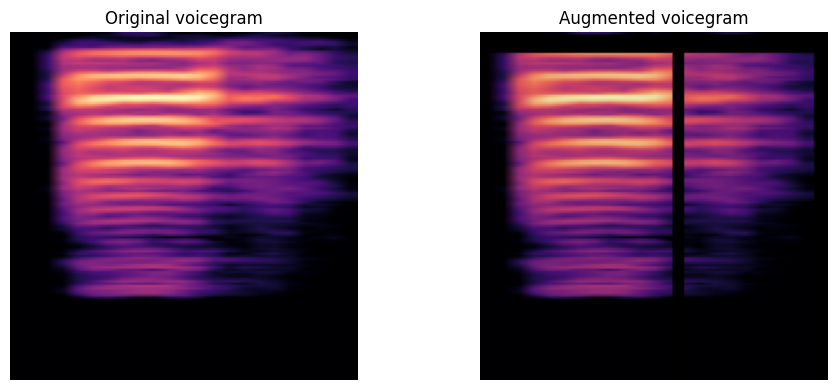

In [12]:
example_arr = np.load(train_df.iloc[0]["spectrogram_path"]).astype(np.float32)
aug_arr = augment_voicegram(example_arr)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(example_arr)
plt.title("Original voicegram")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aug_arr)
plt.title("Augmented voicegram")
plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Model 1: Baseline CNN

This model is a simple image-classification CNN. It acts as our baseline.

It receives a voicegram image and predicts the command class.

In [13]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.40):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 13. Model 2: Proposed Residual-Attention CNN

This is our main contribution.

### Why residual connections?

Residual connections allow information to pass forward more easily. This helps reduce the vanishing-gradient problem in deeper networks.

### Why attention?

Attention helps the model focus on the important time-frequency regions of the voicegram image.

So the proposed model is designed to improve the plain S-CNN architecture mentioned in the research gap.

In [14]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, dropout=0.10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity, inplace=True)
        return out


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        weights = self.pool(x).view(b, c)
        weights = self.fc(weights).view(b, c, 1, 1)
        return x * weights


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max_value, _ = torch.max(x, dim=1, keepdim=True)
        attention = self.sigmoid(self.conv(torch.cat([avg, max_value], dim=1)))
        return x * attention


class ResidualAttentionCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.45):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.stage1 = nn.Sequential(
            ResidualBlock(32, 64, stride=2, dropout=0.10),
            ResidualBlock(64, 64, stride=1, dropout=0.10),
        )
        self.attn1 = nn.Sequential(ChannelAttention(64), SpatialAttention())

        self.stage2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, dropout=0.15),
            ResidualBlock(128, 128, stride=1, dropout=0.15),
        )
        self.attn2 = nn.Sequential(ChannelAttention(128), SpatialAttention())

        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, dropout=0.20),
            ResidualBlock(256, 256, stride=1, dropout=0.20),
        )
        self.attn3 = nn.Sequential(ChannelAttention(256), SpatialAttention())

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.attn1(self.stage1(x))
        x = self.attn2(self.stage2(x))
        x = self.attn3(self.stage3(x))
        x = self.classifier(x)
        return x

## 14. Training and evaluation helper functions

These functions train the models, store the best validation checkpoint, and compute metrics.

In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_class_weights(train_dataframe, num_classes):
    counts = train_dataframe["label_idx"].value_counts().reindex(range(num_classes), fill_value=1).values
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    avg_loss = total_loss / max(1, total_samples)
    avg_acc = total_correct / max(1, total_samples)
    return avg_loss, avg_acc


def train_model(model, model_name, train_loader, val_loader, train_dataframe, num_classes):
    model = model.to(DEVICE)
    class_weights = make_class_weights(train_dataframe, num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

    best_val_loss = float("inf")
    best_path = MODELS_DIR / f"{model_name}_best.pt"
    patience_counter = 0

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    print(f"\nTraining {model_name}")
    print("Trainable parameters:", count_parameters(model))

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_one_epoch(model, val_loader, criterion, optimizer=None)
        scheduler.step(val_loss)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "model_state_dict": model.state_dict(),
                "label_to_idx": label_to_idx,
                "idx_to_label": idx_to_label,
                "model_name": model_name,
                "image_size": IMAGE_SIZE,
                "n_mels": N_MELS,
                "target_sample_rate": TARGET_SAMPLE_RATE,
            }, best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Load best checkpoint back into the model.
    checkpoint = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    history_df = pd.DataFrame(history)
    history_df.to_csv(RESULTS_DIR / f"{model_name}_history.csv", index=False)
    return model, history_df, best_path


def get_predictions(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1).cpu().numpy()

            all_true.extend(y.numpy().tolist())
            all_pred.extend(preds.tolist())
            all_prob.extend(probs.cpu().numpy().tolist())

    return np.array(all_true), np.array(all_pred), np.array(all_prob)


def evaluate_model(model, loader, model_name, label_names):
    y_true, y_pred, y_prob = get_predictions(model, loader)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    # For isolated word/command classification, WRA is equivalent to overall accuracy.
    word_recognition_accuracy = accuracy

    metrics = {
        "model": model_name,
        "accuracy": accuracy,
        "word_recognition_accuracy": word_recognition_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }

    print(f"\nEvaluation results for {model_name}")
    for key, value in metrics.items():
        if key != "model":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    cmatrix = confusion_matrix(y_true, y_pred, labels=list(range(len(label_names))))
    return metrics, cmatrix, y_true, y_pred, y_prob

## 15. Train both models

This cell trains:

1. Baseline CNN
2. Proposed Residual-Attention CNN

If training takes too long, reduce `EPOCHS`, `MAX_CLASSES`, or `MAX_SAMPLES_PER_CLASS` in the configuration cell.

In [16]:
num_classes = len(label_names)

baseline_model = BaselineCNN(num_classes=num_classes)
proposed_model = ResidualAttentionCNN(num_classes=num_classes)

baseline_model, baseline_history, baseline_best_path = train_model(
    baseline_model,
    "baseline_cnn",
    train_loader,
    val_loader,
    train_df,
    num_classes,
)

proposed_model, proposed_history, proposed_best_path = train_model(
    proposed_model,
    "proposed_residual_attention_cnn",
    train_loader,
    val_loader,
    train_df,
    num_classes,
)

print("Baseline best checkpoint:", baseline_best_path)
print("Proposed best checkpoint:", proposed_best_path)


Training baseline_cnn
Trainable parameters: 288746
Epoch 01/12 | train_loss=2.3672, train_acc=0.0982 | val_loss=2.4152, val_acc=0.1000
Epoch 02/12 | train_loss=2.2740, train_acc=0.1411 | val_loss=2.4731, val_acc=0.1000
Epoch 03/12 | train_loss=2.2185, train_acc=0.1839 | val_loss=2.2270, val_acc=0.1333
Epoch 04/12 | train_loss=2.1590, train_acc=0.1625 | val_loss=2.2244, val_acc=0.1083
Epoch 05/12 | train_loss=2.1190, train_acc=0.2214 | val_loss=2.3173, val_acc=0.1167
Epoch 06/12 | train_loss=2.0859, train_acc=0.1750 | val_loss=1.9050, val_acc=0.2417
Epoch 07/12 | train_loss=2.0335, train_acc=0.1839 | val_loss=1.9055, val_acc=0.2083
Epoch 08/12 | train_loss=2.0191, train_acc=0.2196 | val_loss=1.8827, val_acc=0.2917
Epoch 09/12 | train_loss=1.9764, train_acc=0.2107 | val_loss=1.9223, val_acc=0.2333
Epoch 10/12 | train_loss=1.9512, train_acc=0.2268 | val_loss=1.8345, val_acc=0.2833
Epoch 11/12 | train_loss=1.9372, train_acc=0.2321 | val_loss=1.8049, val_acc=0.2917
Epoch 12/12 | train_loss

## 16. Training graphs

These graphs show whether the models are learning properly.

- Training accuracy should generally increase.
- Validation accuracy should also increase.
- If training accuracy is high but validation accuracy is low, the model is overfitting.

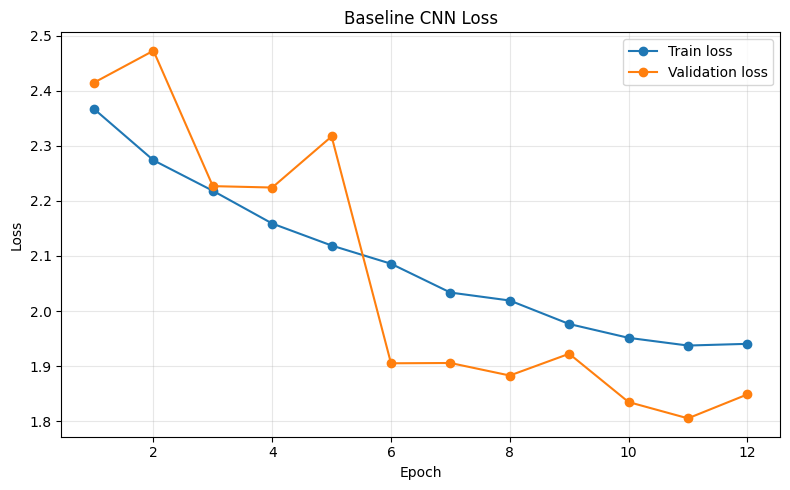

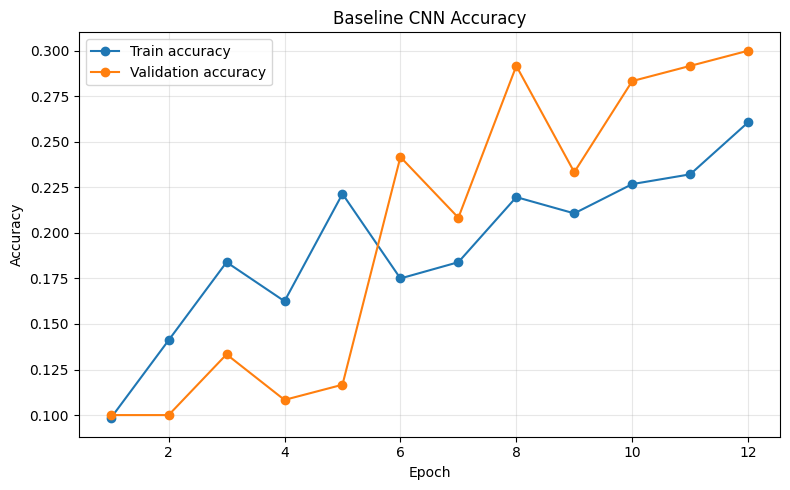

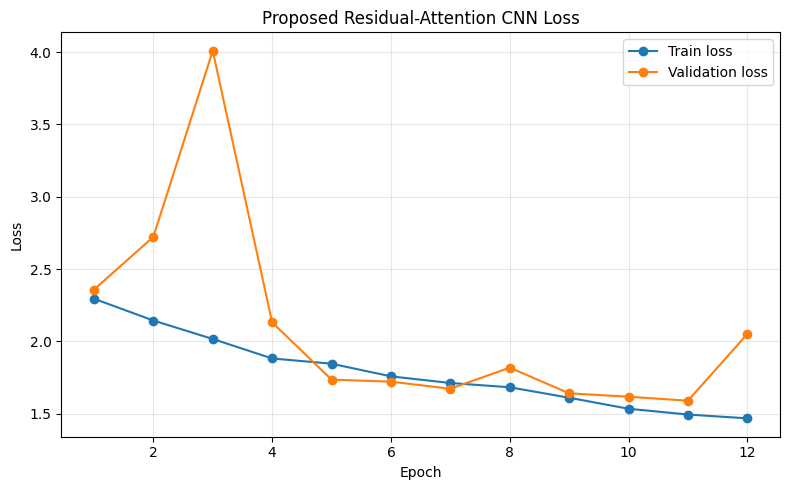

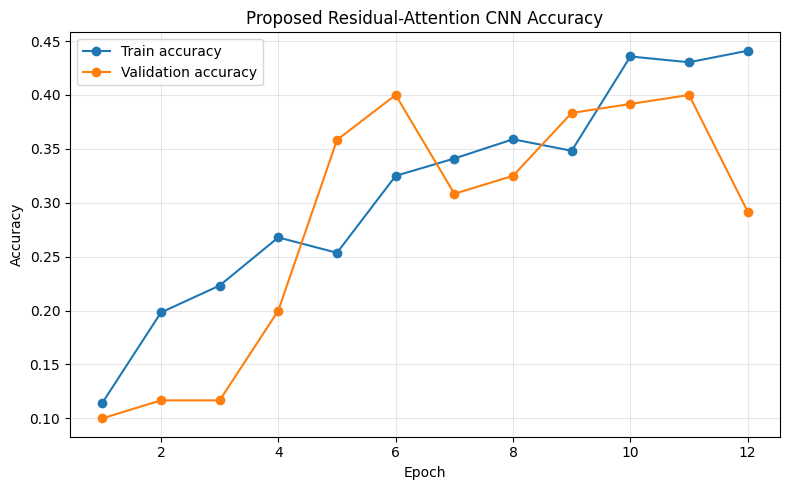

In [17]:
def plot_history(history_df, title_prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="Train accuracy")
    plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="Validation accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(baseline_history, "Baseline CNN")
plot_history(proposed_history, "Proposed Residual-Attention CNN")

## 17. Test-set evaluation

Now we evaluate both models on unseen test data.

In [18]:
baseline_metrics, baseline_cm, baseline_y_true, baseline_y_pred, baseline_y_prob = evaluate_model(
    baseline_model,
    test_loader,
    "Baseline CNN",
    label_names,
)

proposed_metrics, proposed_cm, proposed_y_true, proposed_y_pred, proposed_y_prob = evaluate_model(
    proposed_model,
    test_loader,
    "Proposed Residual-Attention CNN",
    label_names,
)

comparison_df = pd.DataFrame([baseline_metrics, proposed_metrics])
comparison_df.to_csv(RESULTS_DIR / "model_comparison_metrics.csv", index=False)
comparison_df


Evaluation results for Baseline CNN
accuracy: 0.3333
word_recognition_accuracy: 0.3333
macro_precision: 0.3043
macro_recall: 0.3333
macro_f1: 0.2704

Classification report:
                      precision    recall  f1-score   support

            aggiungi       0.41      0.92      0.56        12
    chiama_emergenza       0.50      0.25      0.33        12
chiama_ultimo_numero       0.00      0.00      0.00        12
         deseleziona       0.23      0.83      0.36        12
                  no       0.38      0.50      0.43        12
      nuovo_contatto       0.75      0.25      0.38        12
                otto       0.20      0.08      0.12        12
               sette       0.17      0.08      0.11        12
                stop       0.42      0.42      0.42        12
   vai_nei_preferiti       0.00      0.00      0.00        12

            accuracy                           0.33       120
           macro avg       0.30      0.33      0.27       120
        weighted a

,model,accuracy,word_recognition_accuracy,macro_precision,macro_recall,macro_f1
0,Baseline CNN,0.333333,0.333333,0.304301,0.333333,0.270358
1,Proposed Residual-Attention CNN,0.358333,0.358333,0.352336,0.358333,0.324429


## 18. Model comparison graph

This graph directly compares the baseline and proposed model.

<Figure size 1000x500 with 0 Axes>

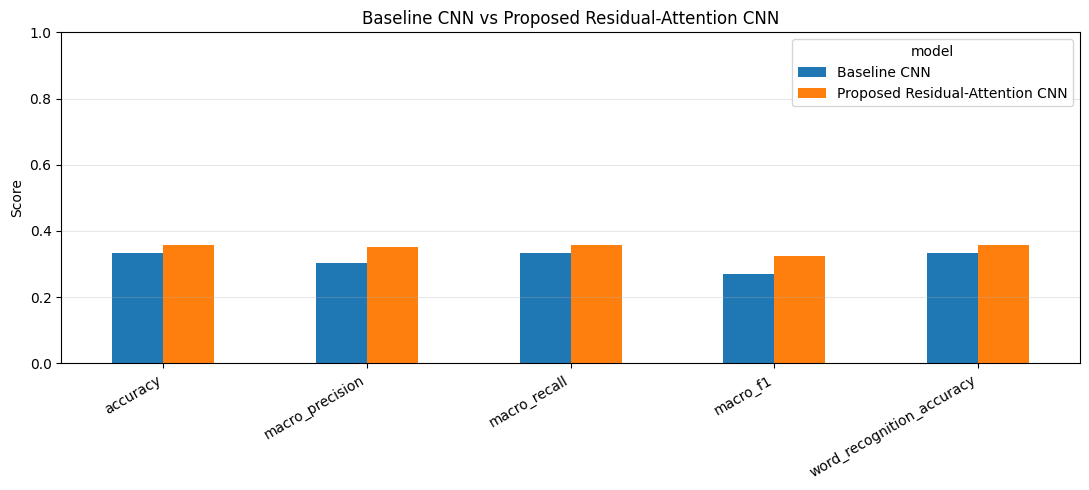

In [19]:
metrics_to_plot = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "word_recognition_accuracy"]
plot_df = comparison_df.set_index("model")[metrics_to_plot]

plt.figure(figsize=(10, 5))
plot_df.T.plot(kind="bar", figsize=(11, 5))
plt.title("Baseline CNN vs Proposed Residual-Attention CNN")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=30, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Confusion matrices

A confusion matrix shows which commands are being confused with other commands.

Rows = true labels.  
Columns = predicted labels.

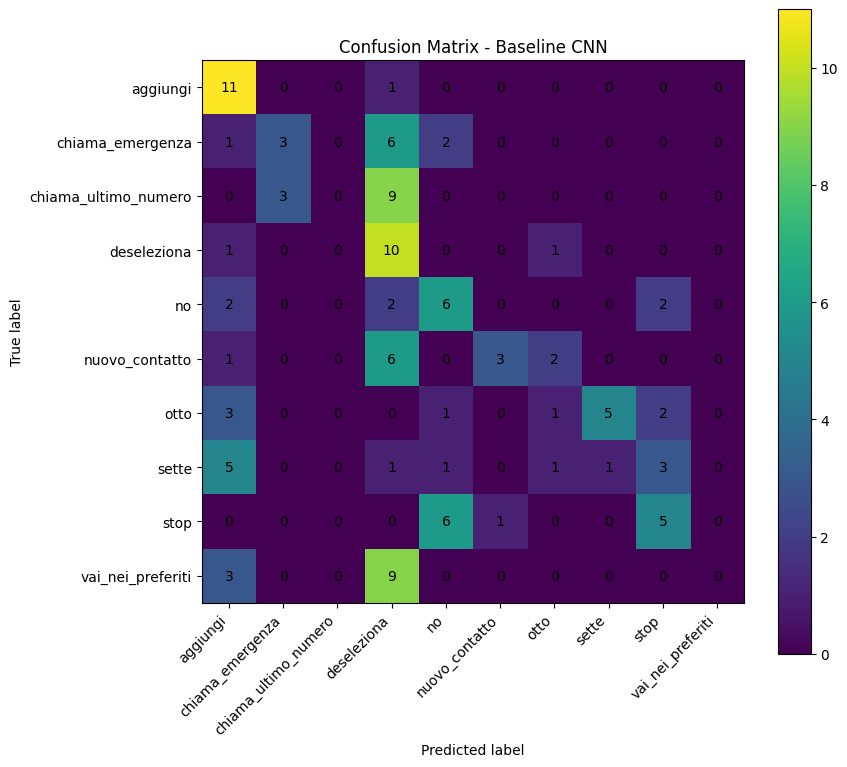

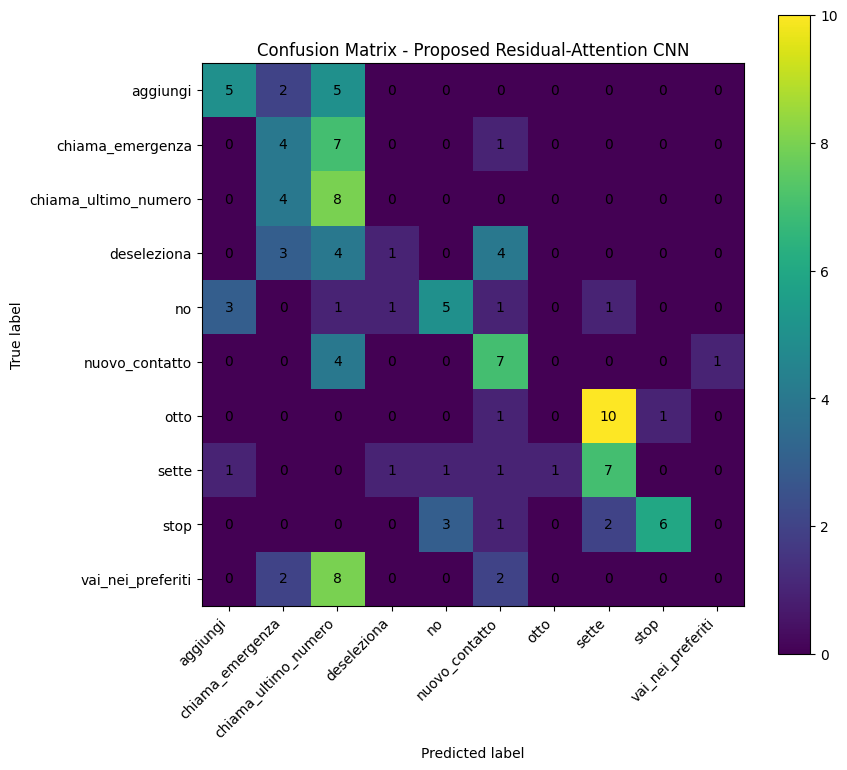

In [20]:
def plot_confusion_matrix(cmatrix, labels, title):
    plt.figure(figsize=(9, 8))
    plt.imshow(cmatrix, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    threshold = cmatrix.max() / 2 if cmatrix.max() > 0 else 0
    for i in range(cmatrix.shape[0]):
        for j in range(cmatrix.shape[1]):
            value = cmatrix[i, j]
            plt.text(j, i, str(value), ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(baseline_cm, label_names, "Confusion Matrix - Baseline CNN")
plot_confusion_matrix(proposed_cm, label_names, "Confusion Matrix - Proposed Residual-Attention CNN")

## 20. Correct and wrong prediction examples

This helps explain what the model learned and where it still fails.

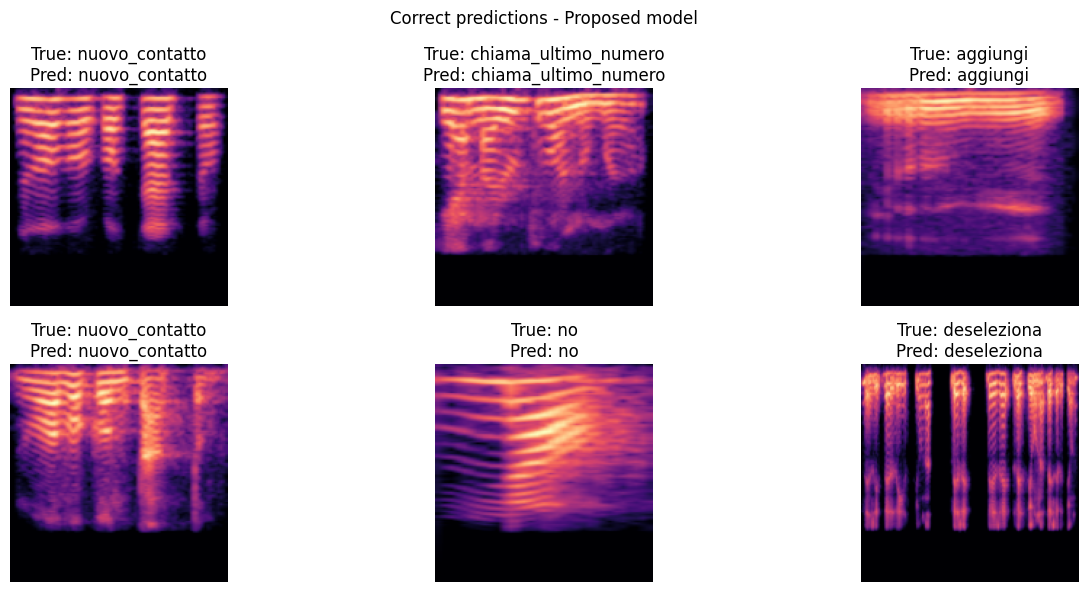

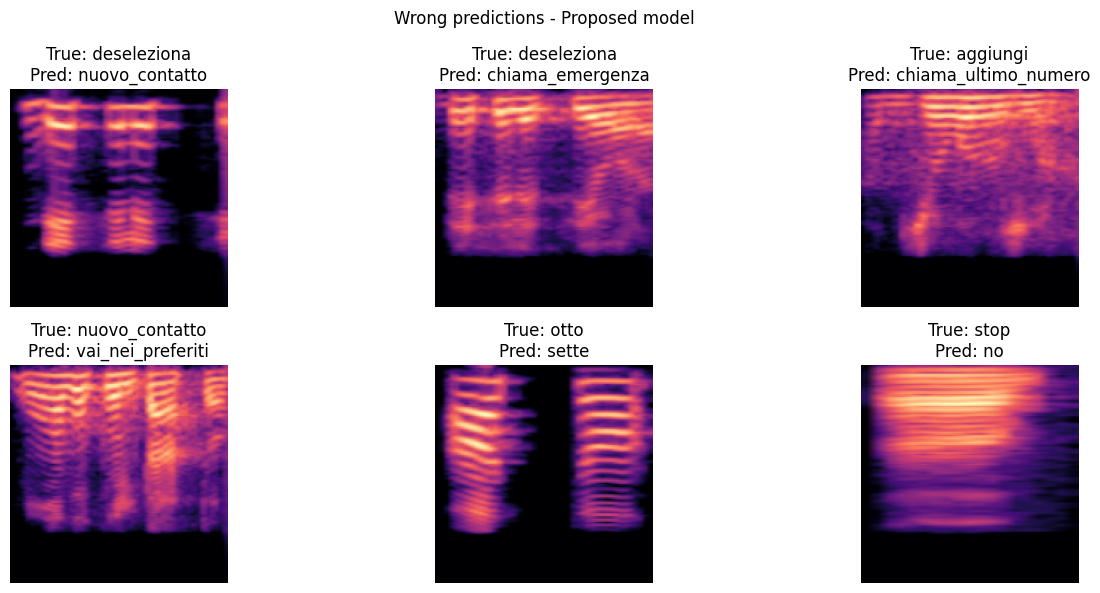

In [21]:
def show_prediction_examples(test_dataframe, y_true, y_pred, title, max_examples=6, show_correct=True):
    indices = np.where((y_true == y_pred) if show_correct else (y_true != y_pred))[0]
    if len(indices) == 0:
        print("No examples found for:", title)
        return

    indices = indices[:max_examples]
    plt.figure(figsize=(14, 6))
    for plot_idx, data_idx in enumerate(indices, start=1):
        row = test_dataframe.iloc[data_idx]
        arr = np.load(row["spectrogram_path"])
        true_label = idx_to_label[int(y_true[data_idx])]
        pred_label = idx_to_label[int(y_pred[data_idx])]

        plt.subplot(2, math.ceil(max_examples / 2), plot_idx)
        plt.imshow(arr)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_prediction_examples(test_df, proposed_y_true, proposed_y_pred, "Correct predictions - Proposed model", show_correct=True)
show_prediction_examples(test_df, proposed_y_true, proposed_y_pred, "Wrong predictions - Proposed model", show_correct=False)

## 21. Single-audio prediction function

This function takes one audio file, converts it into a voicegram, and predicts the command.

In [22]:
def predict_audio_file(audio_path, model, top_k=3):
    model.eval()
    arr = audio_to_voicegram_array(audio_path)
    x = torch.tensor(np.ascontiguousarray(arr.transpose(2, 0, 1)), dtype=torch.float32)
    x = x.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    top_indices = probs.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            "label": idx_to_label[int(idx)],
            "confidence": float(probs[idx]),
        })
    return pd.DataFrame(results)

# Demo prediction on one test audio file
example_test_audio = test_df.iloc[0]["audio_path"]
print("Audio path:", example_test_audio)
predict_audio_file(example_test_audio, proposed_model, top_k=3)

Audio path: easycall_voicegram_project_workspace/raw_audio/audio/nuovo_contatto/easycall_f06_nuovo_contatto_00059.wav


,label,confidence
0,nuovo_contatto,0.473709
1,vai_nei_preferiti,0.220000
2,chiama_ultimo_numero,0.120322


## 22. Final project conclusion

### What we implemented

This notebook implemented an end-to-end dysarthric command-recognition system using the Speech Vision idea.

The system converted speech audio into visual Mel-spectrogram/voicegram-like images and trained two models:

1. **Baseline CNN**
2. **Proposed Residual-Attention CNN**

### Research gap addressed

The original Speech Vision paper mentioned that its S-CNN architecture could be improved to reduce vanishing-gradient issues and representational bottlenecks. This project addressed that gap by adding:

- Residual connections
- Channel attention
- Spatial attention
- Stronger spectrogram augmentation

### Metrics used

The notebook reports:

- Accuracy
- Word Recognition Accuracy
- Macro Precision
- Macro Recall
- Macro F1-score
- Classification report
- Confusion matrix
- Training and validation graphs

### Final claim

If the proposed model achieves better validation/test scores than the baseline model, then the project supports the claim that residual-attention learning can improve voicegram-based dysarthric command recognition under limited-data conditions.

If the proposed model does not outperform the baseline, that is still a valid research outcome. In that case, the conclusion should say that the heavier architecture may require more data, better tuning, or longer training.

## 23. Suggested report-ready summary

You can use this in your project report or presentation.

> This project extends the Speech Vision approach for dysarthric automatic speech recognition by converting command speech into voicegram-like Mel-spectrogram images and classifying them using deep learning. The baseline system uses a conventional convolutional neural network, while the proposed system introduces residual learning and attention mechanisms to reduce vanishing-gradient effects and improve feature selection. The model is evaluated on the EasyCall dysarthric command-speech dataset using accuracy, Word Recognition Accuracy, precision, recall, F1-score, and confusion matrix analysis.